### Purpose

This notebook performs a full exploratory and analytical analysis to evaluate whether proximity to Saltwater Injection Wells (SWIWs) affects oil and gas well production in Ohio. Using geospatial processing, the notebook converts well locations into GeoDataFrames and employs a KD-Tree with haversine geometry to efficiently compute the nearest SWIW for every production well, exporting those distances for further analysis. The workflow includes visualizations such as distance distributions and a map showing wells colored by proximity to the nearest SWIW. Building on the spatial results, the notebook performs multiple regression approaches, including basic OLS, cluster-robust specifications, and a generalized additive model (GAM), to evaluate whether SWIW proximity is associated with variations in oil and gas production. The analysis concludes with diagnostic plots and partial-effect visualizations to characterize potential nonlinear or time-varying relationships.

### Load Libraries

In [1]:
import pandas as pd
import numpy as np
from geopy.distance import geodesic
import geopandas as gpd
from shapely.geometry import Point
from tqdm import tqdm

### Load Data

In [14]:
well_info = pd.read_csv('../data/final/well_information_final.csv')
permits = pd.read_csv('../data/final/permit_plug_list_final.csv')

### Create GeoDataFrames for each dataset

In [ ]:
well_info = well_info.dropna(subset=['WELL LATITUDE', 'WELL LONGITUDE'])
permits = permits.dropna(subset=['WH_LAT', 'WH_LONG'])

### Identify (SWIW)

In [4]:
swiw_df = permits[
    (permits['PROP_WLTYPE'] == 'SW_R') |
    (permits['APP_TYP_Description'] == 'Convert SWIW') |
    (permits['APP_TYP_Description'] == 'Salt Water Injection Well New Well')
]

prod_well_df = well_info[~well_info['API WELL NUMBER'].isin(swiw_df['API_WELLNO'])]

print(f"Total wells: {len(prod_well_df)}")
print(f"Saltwater wells: {len(swiw_df)}")

Total wells: 73593
Saltwater wells: 405


In [5]:
# Find all values of APP_TYP_Description with 'SWIW' or 'Inject' or 'inject' in them
swiw_types = permits[permits['APP_TYP_Description'].str.contains('SWIW|Inject|inject', na=False)]['APP_TYP_Description'].unique()
swiw_types

array(['Convert SWIW', 'Salt Water Injection Well New Well',
       'Reissue Salt Water Injection Well'], dtype=object)

### Compute pairwise distances between wells

In [6]:
from scipy.spatial import cKDTree
import numpy as np

def nearest_swiw(prod_df, swiw_df):
    # convert to radians for vectorized haversine projections
    prod_lat = np.radians(prod_df["WELL LATITUDE"].values)
    prod_lon = np.radians(prod_df["WELL LONGITUDE"].values)

    swiw_lat = np.radians(swiw_df["WH_LAT"].values)
    swiw_lon = np.radians(swiw_df["WH_LONG"].values)

    # project to 3D unit sphere for KD-tree
    def to_cartesian(lat, lon):
        x = np.cos(lat) * np.cos(lon)
        y = np.cos(lat) * np.sin(lon)
        z = np.sin(lat)
        return np.vstack((x, y, z)).T

    prod_xyz = to_cartesian(prod_lat, prod_lon)
    swiw_xyz = to_cartesian(swiw_lat, swiw_lon)

    tree = cKDTree(swiw_xyz)
    dist, idx = tree.query(prod_xyz, k=1)

    # Convert chord distance (3D) to great-circle km
    earth_radius = 6371
    great_circle = 2 * earth_radius * np.arcsin(np.clip(dist/2, -1, 1))

    result = prod_df.copy()
    result["Nearest_SWIW_API"] = swiw_df.iloc[idx]["API_WELLNO"].values
    result["Nearest_SWIW_km"] = great_circle

    return result

### Compute Nearest Wells and Export

In [7]:
nearest_swiw_df = nearest_swiw(prod_well_df, swiw_df)
nearest_swiw_df.to_csv('../data/distance/well_to_nearest_saltwater_updated.csv', index=False)

In [8]:
nearest_swiw_df = pd.read_csv('../data/distance/well_to_nearest_saltwater_updated.csv')

c:\Users\willf\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


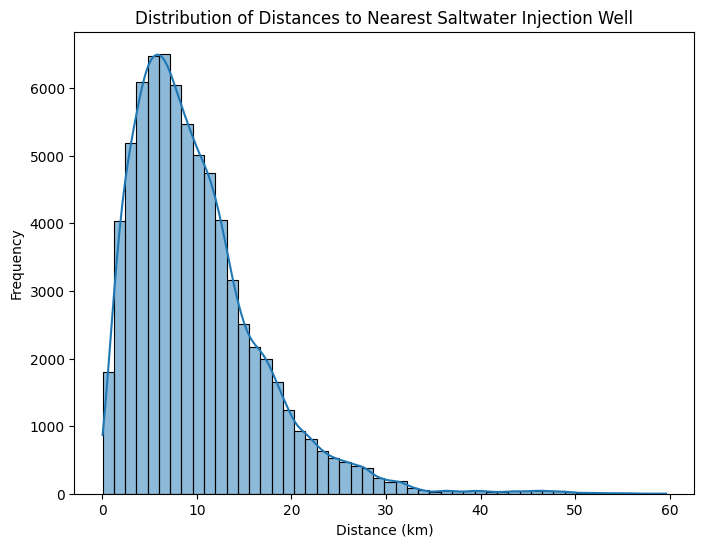

In [9]:
# Generate distribution plots for distances
import matplotlib.pyplot as plt
import seaborn as sns
nearest_2 = nearest_swiw_df[nearest_swiw_df['Nearest_SWIW_km'] < 60]

plt.figure(figsize=(8, 6))
sns.histplot(nearest_2['Nearest_SWIW_km'], bins=50, kde=True)
plt.title('Distribution of Distances to Nearest Saltwater Injection Well')
plt.xlabel('Distance (km)')
plt.ylabel('Frequency')
plt.show()

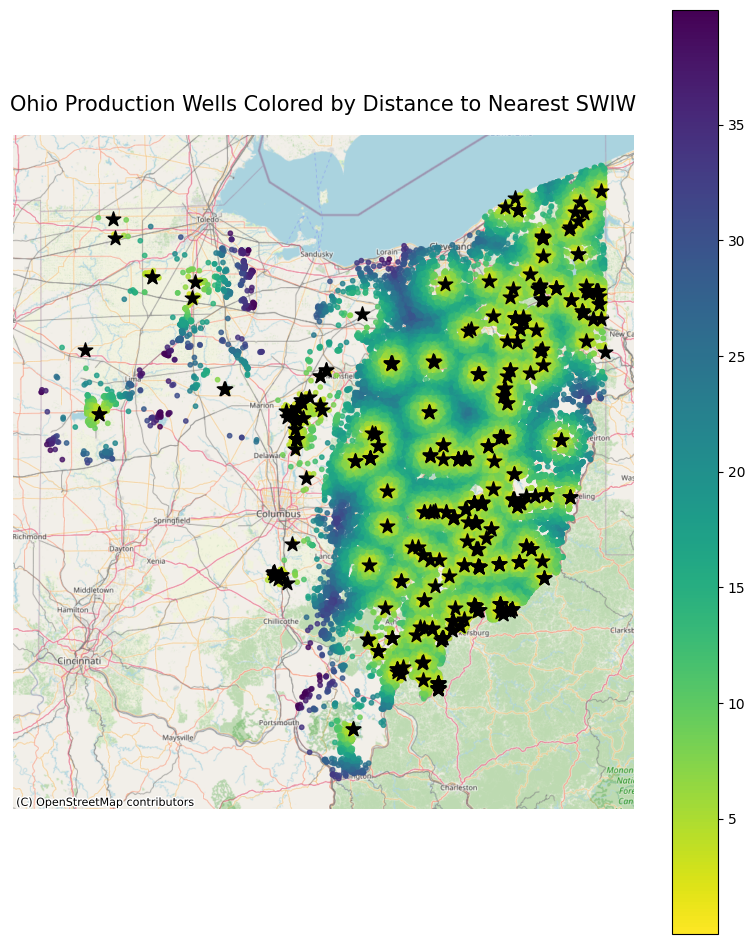

In [11]:
import contextily as ctx

really_nearest = nearest_swiw_df[nearest_swiw_df['Nearest_SWIW_km'] < 40]

prod_gdf = gpd.GeoDataFrame(
    really_nearest,
    geometry=gpd.points_from_xy(really_nearest["WELL LONGITUDE"], really_nearest["WELL LATITUDE"]),
    crs="EPSG:4326"
)

swiw_gdf = gpd.GeoDataFrame(
    swiw_df,
    geometry=gpd.points_from_xy(swiw_df["WH_LONG"], swiw_df["WH_LAT"]),
    crs="EPSG:4326"
)

prod_gdf = prod_gdf.to_crs(epsg=3857)
swiw_gdf = swiw_gdf.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(10, 12))

prod_gdf.plot(
    ax=ax,
    column="Nearest_SWIW_km",
    cmap="viridis_r",
    markersize=10,
    alpha=0.8,
    legend=True
)

swiw_gdf.plot(
    ax=ax,
    color="black",
    marker="*",
    markersize=120,
    label="SWIW"
)

ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

ax.set_title("Ohio Production Wells Colored by Distance to Nearest SWIW", fontsize=15)
ax.set_axis_off()

plt.show()

In [12]:
# Basic Regression - Distance to Nearest Saltwater Injection Well vs. Well Production

import statsmodels.api as sm
distance_data = pd.read_csv('../data/distance/well_to_nearest_saltwater_updated.csv')
production_data = pd.read_csv('../data/final/annual_production_final.csv')
regression_data = pd.merge(distance_data, production_data, left_on='API WELL NUMBER', right_on='API Number')

regression_data = regression_data[(regression_data['Production Year'] == 2024) & (regression_data['Quarter (1, 2, 3, 4, n/a)'].isna()) & (regression_data['Gas (Mcf)'] > 0) & (regression_data['Gas (Mcf)'] < 10000)]

X = regression_data['Nearest_SWIW_km']
y = regression_data['Gas (Mcf)']
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:              Gas (Mcf)   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                   0.07431
Date:                Fri, 05 Dec 2025   Prob (F-statistic):              0.785
Time:                        23:37:56   Log-Likelihood:            -1.8624e+05
No. Observations:               21827   AIC:                         3.725e+05
Df Residuals:                   21825   BIC:                         3.725e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const             958.4516     15.501     

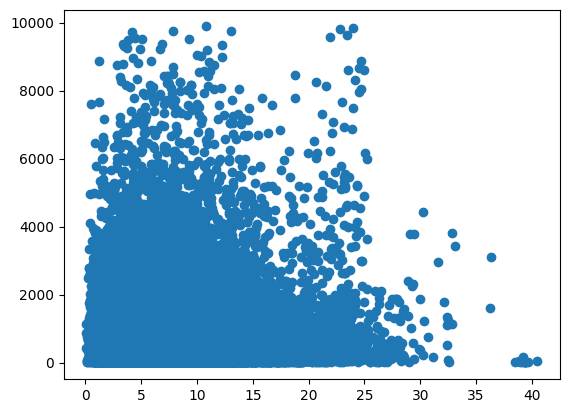

In [13]:
plt.scatter(regression_data['Nearest_SWIW_km'], regression_data['Gas (Mcf)'])

In [14]:
# Same thing for oil production
distance_data = pd.read_csv('../data/distance/well_to_nearest_saltwater_updated.csv')
production_data = pd.read_csv('../data/final/annual_production_final.csv')
regression_data = pd.merge(distance_data, production_data, left_on='API WELL NUMBER', right_on='API Number')

regression_data = regression_data[(regression_data['Production Year'] == 2024) & (regression_data['Quarter (1, 2, 3, 4, n/a)'].isna()) & (regression_data['Oil (Bbls)'] > 0)]

X = regression_data['Nearest_SWIW_km']
y = regression_data['Oil (Bbls)']
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             Oil (Bbls)   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     11.16
Date:                Fri, 05 Dec 2025   Prob (F-statistic):           0.000836
Time:                        23:38:05   Log-Likelihood:                -92979.
No. Observations:               13594   AIC:                         1.860e+05
Df Residuals:                   13592   BIC:                         1.860e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const             111.0484      3.381     

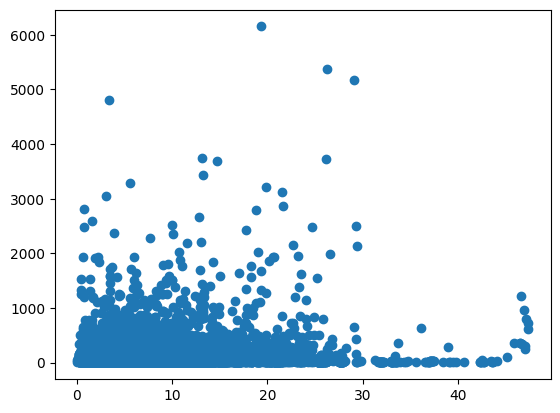

In [15]:
plt.scatter(regression_data['Nearest_SWIW_km'], regression_data['Oil (Bbls)'])

In [16]:
# Quarterly DiD

from datetime import datetime
import statsmodels.formula.api as smf

well_info = pd.read_csv("../data/final/well_information_final.csv")
dist_info = pd.read_csv("../data/distance/well_to_nearest_saltwater_updated.csv")
prod = pd.read_csv("../data/final/quarterly_production_final.csv")
permits = pd.read_csv("../data/final/permit_plug_list_final.csv")

swiw = permits[
    (permits['PROP_WLTYPE'] == 'SW_R') |
    (permits['APP_TYP_Description'] == 'Convert SWIW') |
    (permits['APP_TYP_Description'] == 'Salt Water Injection Well New Well')
].copy()
swiw = swiw[["API_WELLNO", "DT_APP_ISSUED", "WH_LAT", "WH_LONG"]]
swiw.rename(columns={"API_WELLNO": "API"}, inplace=True)
swiw["permit_date"] = pd.to_datetime(swiw["DT_APP_ISSUED"], errors="coerce")

dist_info.rename(columns={"API WELL NUMBER": "API"}, inplace=True)
prod.rename(columns={"API Number": "API"}, inplace=True)

prod = prod.merge(dist_info, on="API", how="left")

prod = prod.merge(
    swiw[["API", "permit_date"]].rename(columns={"API": "Nearest_SWIW_API"}),
    on="Nearest_SWIW_API", how="left"
)

# Take this out and switch to annual and quarterly if we want to consider both
prod = prod[prod['Quarter (1, 2, 3, 4, n/a)'].isin([1,2,3,4])]

def row_to_qdate(row):
    yr = row["Production Year"]
    q = row["Quarter (1, 2, 3, 4, n/a)"]
    if str(q).lower() in ["na", "n/a", None]:
        # annual → assign Q4
        return pd.Period(f"{yr}Q4").to_timestamp('Q')
    else:
        return pd.Period(f"{yr}Q{int(q)}").to_timestamp('Q')

prod["qdate"] = prod.apply(row_to_qdate, axis=1)

prod["rel_days"] = (prod["qdate"] - prod["permit_date"]).dt.days
prod["rel_quarters"] = (prod["rel_days"] / 90).round().astype("Int64")
prod = prod[~prod['rel_quarters'].isna()]
prod["post"] = (prod["rel_quarters"] >= 0).astype(int)

prod["inv_dist"] = 1 / (prod["Nearest_SWIW_km"] + 0.1)  # avoid div by zero
prod["log_inv_dist"] = np.log(prod["inv_dist"])

# prod = prod[prod['Nearest_SWIW_km'] <= 3]

model = smf.ols(
    formula="""
        Q("Oil (Bbls)") ~ post * log_inv_dist
        + C(API) + C(qdate)
    """,
    data=prod
).fit(cov_type="cluster", cov_kwds={"groups": prod["API"]})

print(model.summary())

c:\Users\willf\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:1896: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 3466, but rank is 1
  warnings.warn('covariance of constraints does not have full '
c:\Users\willf\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\regression\linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))


                            OLS Regression Results                            
Dep. Variable:        Q("Oil (Bbls)")   R-squared:                       0.456
Model:                            OLS   Adj. R-squared:                  0.445
Method:                 Least Squares   F-statistic:                -9.591e-06
Date:                Fri, 05 Dec 2025   Prob (F-statistic):               1.00
Time:                        23:45:16   Log-Likelihood:            -1.7885e+06
No. Observations:              177756   AIC:                         3.584e+06
Df Residuals:                  174290   BIC:                         3.619e+06
Df Model:                        3465                                         
Covariance Type:              cluster                                         
                                                   coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------

In [17]:
# Quarterly DiD on wells within 3 km
prod_fil = prod[prod['Nearest_SWIW_km'] <= 3]

model = smf.ols(
    formula="""
        Q("Oil (Bbls)") ~ post * log_inv_dist
        + C(API) + C(qdate)
    """,
    data=prod_fil
).fit(cov_type="cluster", cov_kwds={"groups": prod_fil["API"]})

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        Q("Oil (Bbls)")   R-squared:                       0.430
Model:                            OLS   Adj. R-squared:                  0.418
Method:                 Least Squares   F-statistic:                 3.312e+04
Date:                Fri, 05 Dec 2025   Prob (F-statistic):               0.00
Time:                        23:45:18   Log-Likelihood:            -1.4040e+05
No. Observations:               13918   AIC:                         2.814e+05
Df Residuals:                   13620   BIC:                         2.836e+05
Df Model:                         297                                         
Covariance Type:              cluster                                         
                                                   coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------

c:\Users\willf\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:1896: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 298, but rank is 51
  warnings.warn('covariance of constraints does not have full '


In [36]:
# Annual Data Processing for DiD

from datetime import datetime
import statsmodels.formula.api as smf

well_info = pd.read_csv("../data/final/well_information_final.csv")
dist_info = pd.read_csv("../data/distance/well_to_nearest_saltwater_updated.csv")
prod = pd.read_csv("../data/final/annual_production_final.csv")
permits = pd.read_csv("../data/final/permit_plug_list_final.csv")

swiw = permits[
    (permits['PROP_WLTYPE'] == 'SW_R') |
    (permits['APP_TYP_Description'] == 'Convert SWIW') |
    (permits['APP_TYP_Description'] == 'Salt Water Injection Well New Well')
].copy()
swiw = swiw[["API_WELLNO", "DT_APP_ISSUED", "WH_LAT", "WH_LONG"]]
swiw.rename(columns={"API_WELLNO": "API"}, inplace=True)
swiw["permit_date"] = pd.to_datetime(swiw["DT_APP_ISSUED"], errors="coerce")

dist_info.rename(columns={"API WELL NUMBER": "API"}, inplace=True)
prod.rename(columns={"API Number": "API"}, inplace=True)

prod = prod.merge(dist_info, on="API", how="left")

prod = prod[prod['Nearest_SWIW_km'] <= 3]

prod = prod.merge(
    swiw[["API", "permit_date"]].rename(columns={"API": "Nearest_SWIW_API"}),
    on="Nearest_SWIW_API", how="left"
)

# Filter to annual data
prod = prod[
    prod['Quarter (1, 2, 3, 4, n/a)'].isna() |
    (prod['Quarter (1, 2, 3, 4, n/a)'].astype(str).str.lower().isin(["na", "n/a"]))
]

def row_to_qdate(row):
    yr = row["Production Year"]
    q = row["Quarter (1, 2, 3, 4, n/a)"]

    if pd.isna(q) or str(q).lower() in ["na", "n/a"]:
        return pd.Period(f"{yr}Q4").to_timestamp(how="end")
    else:
        return pd.Period(f"{yr}Q{int(q)}").to_timestamp(how="end")

prod["qdate"] = prod.apply(row_to_qdate, axis=1)

prod["rel_days"] = (prod["qdate"] - prod["permit_date"]).dt.days
prod["rel_quarters"] = (prod["rel_days"] / 90).round().astype("Int64")
prod = prod[~prod['rel_quarters'].isna()]
prod["post"] = (prod["rel_quarters"] >= 0).astype(int)
prod["post_lag_1"] = (prod["rel_quarters"] >= 4).astype(int)
prod["post_lag_2"] = (prod["rel_quarters"] >= 8).astype(int)

prod["inv_dist"] = 1 / (prod["Nearest_SWIW_km"] + 0.1)  # avoid div by zero
prod["log_inv_dist"] = np.log(prod["inv_dist"])

In [37]:
# Filter data for annual DiD
mean_prod = prod.groupby('API')['Oil (Bbls)'].mean()
bad_prod_wells = mean_prod[mean_prod > 200].index.tolist()
prod = prod[~prod["API"].isin(bad_prod_wells)].copy()

mean_prod = prod.groupby('API')['Gas (Mcf)'].mean()
bad_prod_wells = mean_prod[mean_prod > 1000].index.tolist()
prod = prod[~prod["API"].isin(bad_prod_wells)].copy()

In [38]:
# Oil Annual - No lag
pre_post_prod = prod.groupby(["API", "post"])["Oil (Bbls)"].sum().unstack(fill_value=0)
valid_wells = pre_post_prod[(pre_post_prod.get(0, 0) > 0) & (pre_post_prod.get(1, 0) > 0)].index
no_lag_prod = prod[prod["API"].isin(valid_wells)].copy()

no_lag_prod = no_lag_prod[no_lag_prod['Oil (Bbls)'] > 0]

model_no_lag = smf.ols(
    formula=f"""
        Q("Oil (Bbls)") ~ post * log_inv_dist
        + C(API) + C(qdate)
    """,
    data=no_lag_prod
).fit(cov_type="cluster", cov_kwds={"groups": no_lag_prod["API"]})

print(model_no_lag.summary())

c:\Users\willf\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:1896: ValueWarning:

covariance of constraints does not have full rank. The number of constraints is 1338, but rank is 16



                            OLS Regression Results                            
Dep. Variable:        Q("Oil (Bbls)")   R-squared:                       0.647
Model:                            OLS   Adj. R-squared:                  0.626
Method:                 Least Squares   F-statistic:                     277.0
Date:                Sat, 06 Dec 2025   Prob (F-statistic):               0.00
Time:                        00:21:26   Log-Likelihood:            -1.2895e+05
No. Observations:               24801   AIC:                         2.606e+05
Df Residuals:                   23463   BIC:                         2.714e+05
Df Model:                        1337                                         
Covariance Type:              cluster                                         
                                                             coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------

In [39]:
# Oil Annual - 1 Yr Lag
pre_post_prod = prod.groupby(["API", "post_lag_1"])["Oil (Bbls)"].sum().unstack(fill_value=0)
valid_wells = pre_post_prod[(pre_post_prod.get(0, 0) > 0) & (pre_post_prod.get(1, 0) > 0)].index
lag_1_prod = prod[prod["API"].isin(valid_wells)].copy()

lag_1_prod = lag_1_prod[lag_1_prod['Oil (Bbls)'] > 0]

model_lag_1 = smf.ols(
    formula=f"""
        Q("Oil (Bbls)") ~ post_lag_1 * log_inv_dist
        + C(API) + C(qdate)
    """,
    data=lag_1_prod
).fit(cov_type="cluster", cov_kwds={"groups": lag_1_prod["API"]})

print(model_lag_1.summary())

c:\Users\willf\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:1896: ValueWarning:

covariance of constraints does not have full rank. The number of constraints is 1535, but rank is 16



                            OLS Regression Results                            
Dep. Variable:        Q("Oil (Bbls)")   R-squared:                       0.644
Model:                            OLS   Adj. R-squared:                  0.624
Method:                 Least Squares   F-statistic:                -2.311e+11
Date:                Sat, 06 Dec 2025   Prob (F-statistic):               1.00
Time:                        00:22:45   Log-Likelihood:            -1.4782e+05
No. Observations:               28560   AIC:                         2.987e+05
Df Residuals:                   27025   BIC:                         3.114e+05
Df Model:                        1534                                         
Covariance Type:              cluster                                         
                                                             coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------

In [40]:
# Oil Annual - 2 Yr Lag
pre_post_prod = prod.groupby(["API", "post_lag_2"])["Oil (Bbls)"].sum().unstack(fill_value=0)
valid_wells = pre_post_prod[(pre_post_prod.get(0, 0) > 0) & (pre_post_prod.get(1, 0) > 0)].index
lag_2_prod = prod[prod["API"].isin(valid_wells)].copy()

lag_2_prod = lag_2_prod[lag_2_prod['Oil (Bbls)'] > 0]


model_lag_2 = smf.ols(
    formula=f"""
        Q("Oil (Bbls)") ~ post_lag_2 * log_inv_dist
        + C(API) + C(qdate)
    """,
    data=lag_2_prod
).fit(cov_type="cluster", cov_kwds={"groups": lag_2_prod["API"]})

print(model_lag_2.summary())

c:\Users\willf\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:1896: ValueWarning:

covariance of constraints does not have full rank. The number of constraints is 1834, but rank is 1

c:\Users\willf\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\regression\linear_model.py:1884: RuntimeWarning:

invalid value encountered in sqrt



                            OLS Regression Results                            
Dep. Variable:        Q("Oil (Bbls)")   R-squared:                       0.634
Model:                            OLS   Adj. R-squared:                  0.613
Method:                 Least Squares   F-statistic:                 2.591e-08
Date:                Sat, 06 Dec 2025   Prob (F-statistic):               1.00
Time:                        00:23:11   Log-Likelihood:            -1.7436e+05
No. Observations:               33675   AIC:                         3.524e+05
Df Residuals:                   31841   BIC:                         3.678e+05
Df Model:                        1833                                         
Covariance Type:              cluster                                         
                                                             coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------

In [41]:
# Gas Annual - No Lag
pre_post_prod = prod.groupby(["API", "post"])["Gas (Mcf)"].sum().unstack(fill_value=0)
valid_wells = pre_post_prod[(pre_post_prod.get(0, 0) > 0) & (pre_post_prod.get(1, 0) > 0)].index
no_lag_prod_gas = prod[prod["API"].isin(valid_wells)].copy()

no_lag_prod_gas = no_lag_prod_gas[no_lag_prod_gas['Gas (Mcf)'] > 0]

model_no_lag_gas = smf.ols(
    formula=f"""
        Q("Gas (Mcf)") ~ post * log_inv_dist
        + C(API) + C(qdate)
    """,
    data=no_lag_prod_gas
).fit(cov_type="cluster", cov_kwds={"groups": no_lag_prod_gas["API"]})

print(model_no_lag_gas.summary())

c:\Users\willf\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:1896: ValueWarning:

covariance of constraints does not have full rank. The number of constraints is 1699, but rank is 1

c:\Users\willf\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\regression\linear_model.py:1884: RuntimeWarning:

invalid value encountered in sqrt



                            OLS Regression Results                            
Dep. Variable:         Q("Gas (Mcf)")   R-squared:                       0.546
Model:                            OLS   Adj. R-squared:                  0.525
Method:                 Least Squares   F-statistic:                 1.027e-08
Date:                Sat, 06 Dec 2025   Prob (F-statistic):               1.00
Time:                        00:25:34   Log-Likelihood:            -2.8551e+05
No. Observations:               39828   AIC:                         5.744e+05
Df Residuals:                   38129   BIC:                         5.890e+05
Df Model:                        1698                                         
Covariance Type:              cluster                                         
                                                             coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------

In [42]:
# Gas Annual - 1 Year Lag
pre_post_prod = prod.groupby(["API", "post_lag_1"])["Gas (Mcf)"].sum().unstack(fill_value=0)
valid_wells = pre_post_prod[(pre_post_prod.get(0, 0) > 0) & (pre_post_prod.get(1, 0) > 0)].index
lag_1_prod_gas = prod[prod["API"].isin(valid_wells)].copy()

lag_1_prod_gas = lag_1_prod_gas[lag_1_prod_gas['Gas (Mcf)'] > 0]

model_lag_1_gas = smf.ols(
    formula=f"""
        Q("Gas (Mcf)") ~ post_lag_1 * log_inv_dist
        + C(API) + C(qdate)
    """,
    data=lag_1_prod_gas
).fit(cov_type="cluster", cov_kwds={"groups": lag_1_prod_gas["API"]})

print(model_lag_1_gas.summary())

c:\Users\willf\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:1896: ValueWarning:

covariance of constraints does not have full rank. The number of constraints is 1954, but rank is 1

c:\Users\willf\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\regression\linear_model.py:1884: RuntimeWarning:

invalid value encountered in sqrt



                            OLS Regression Results                            
Dep. Variable:         Q("Gas (Mcf)")   R-squared:                       0.550
Model:                            OLS   Adj. R-squared:                  0.529
Method:                 Least Squares   F-statistic:                 3.252e-07
Date:                Sat, 06 Dec 2025   Prob (F-statistic):               1.00
Time:                        00:30:21   Log-Likelihood:            -3.2423e+05
No. Observations:               45382   AIC:                         6.524e+05
Df Residuals:                   43428   BIC:                         6.694e+05
Df Model:                        1953                                         
Covariance Type:              cluster                                         
                                                             coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------

In [ ]:
# Gas Annual - 2 Year Lag
pre_post_prod = prod.groupby(["API", "post_lag_2"])["Gas (Mcf)"].sum().unstack(fill_value=0)
valid_wells = pre_post_prod[(pre_post_prod.get(0, 0) > 0) & (pre_post_prod.get(1, 0) > 0)].index
lag_2_prod_gas = prod[prod["API"].isin(valid_wells)].copy()

lag_2_prod_gas = lag_2_prod_gas[lag_2_prod_gas['Gas (Mcf)'] > 0]

model_lag_2_gas = smf.ols(
    formula=f"""
        Q("Gas (Mcf)") ~ post_lag_2 * log_inv_dist
        + C(API) + C(qdate)
    """,
    data=lag_2_prod_gas
).fit(cov_type="cluster", cov_kwds={"groups": lag_2_prod_gas["API"]})

print(model_lag_2_gas.summary())

c:\Users\willf\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:1896: ValueWarning:

covariance of constraints does not have full rank. The number of constraints is 2134, but rank is 1

c:\Users\willf\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\regression\linear_model.py:1884: RuntimeWarning:

invalid value encountered in sqrt



                            OLS Regression Results                            
Dep. Variable:         Q("Gas (Mcf)")   R-squared:                       0.552
Model:                            OLS   Adj. R-squared:                  0.531
Method:                 Least Squares   F-statistic:                 3.693e-08
Date:                Sat, 06 Dec 2025   Prob (F-statistic):               1.00
Time:                        00:31:06   Log-Likelihood:            -3.4328e+05
No. Observations:               48191   AIC:                         6.908e+05
Df Residuals:                   46057   BIC:                         7.096e+05
Df Model:                        2133                                         
Covariance Type:              cluster                                         
                                                             coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------

In [ ]:
# Save summaries
with open("../results/models/model_no_lag_oil_summary.txt", "w") as f:
    f.write(model_no_lag.summary().as_text())
with open("../results/models/model_lag_1_oil_summary.txt", "w") as f:
    f.write(model_lag_1.summary().as_text())
with open("../results/models/model_lag_2_oil_summary.txt", "w") as f:
    f.write(model_lag_2.summary().as_text())
with open("../results/models/model_no_lag_gas_summary.txt", "w") as f:
    f.write(model_no_lag_gas.summary().as_text())
with open("../results/models/model_lag_1_gas_summary.txt", "w") as f:
    f.write(model_lag_1_gas.summary().as_text())
with open("../results/models/model_lag_2_gas_summary.txt", "w") as f:
    f.write(model_lag_2_gas.summary().as_text())

In [52]:
import plotly.express as px

# Aggregate production per well and compute difference
def aggregate_change(df, post_col):
    agg = df.groupby("API").agg(
        lat=("WELL LATITUDE", "first"),
        lon=("WELL LONGITUDE", "first"),
        pre=("Oil (Bbls)", lambda x: x[df.loc[x.index, post_col]==0].mean()),
        post=("Oil (Bbls)", lambda x: x[df.loc[x.index, post_col]==1].mean())
    ).reset_index()
    # Compute difference (after - before)
    agg["diff"] = agg["post"] - agg["pre"]
    return agg

prod_oil = prod[prod['Oil (Bbls)'] > 0]

pre_post_prod = prod_oil.groupby(["API", "post"])["Oil (Bbls)"].sum().unstack(fill_value=0)
valid_wells = pre_post_prod[(pre_post_prod.get(0, 0) > 0) & (pre_post_prod.get(1, 0) > 0)].index
prod_oil_normal = prod_oil[prod_oil["API"].isin(valid_wells)].copy()

pre_post_prod = prod_oil.groupby(["API", "post_lag_2"])["Oil (Bbls)"].sum().unstack(fill_value=0)
valid_wells = pre_post_prod[(pre_post_prod.get(0, 0) > 0) & (pre_post_prod.get(1, 0) > 0)].index
prod_oil_lag_2_normal = prod_oil[prod_oil["API"].isin(valid_wells)].copy()

well_post = aggregate_change(prod_oil_normal, "post")
well_post_lag = aggregate_change(prod_oil_lag_2_normal, "post_lag_2")
well_post = well_post[well_post['diff'] < 20000]
well_post_lag = well_post_lag[well_post_lag['diff'] < 20000]

def make_centered_map(df, title):
    df = df.loc[df["diff"].notna()].copy()

    max_abs = max(abs(df["diff"].min()), abs(df["diff"].max()))
    vmin, vmax = -max_abs, max_abs

    custom_scale = [
        [0.0, "blue"],
        [0.5, "lightgray"],
        [1.0, "red"]
    ]

    fig = px.scatter_mapbox(
        df,
        lat="lat",
        lon="lon",
        color="diff",
        color_continuous_scale=custom_scale,
        range_color=[vmin, vmax],
        color_continuous_midpoint=0,
        hover_name="API",
        hover_data={"pre": True, "post": True, "diff": True},
        zoom=6,
        height=600,
        title=title
    )
    fig.update_layout(mapbox_style="open-street-map")
    return fig

fig_post = make_centered_map(well_post, "Oil Production Change (Immediate)")
fig_post.show()

fig_post_lag = make_centered_map(well_post_lag, "Oil Production Change (Lagged)")
fig_post_lag.show()

In [51]:
import plotly.express as px

# Aggregate production per well and compute difference
def aggregate_change(df, post_col):
    agg = df.groupby("API").agg(
        lat=("WELL LATITUDE", "first"),
        lon=("WELL LONGITUDE", "first"),
        pre=("Gas (Mcf)", lambda x: x[df.loc[x.index, post_col]==0].mean()),
        post=("Gas (Mcf)", lambda x: x[df.loc[x.index, post_col]==1].mean())
    ).reset_index()
    # Compute difference (after - before)
    agg["diff"] = agg["post"] - agg["pre"]
    return agg

prod_gas = prod[prod['Gas (Mcf)'] > 0]

pre_post_prod = prod_gas.groupby(["API", "post"])["Gas (Mcf)"].sum().unstack(fill_value=0)
valid_wells = pre_post_prod[(pre_post_prod.get(0, 0) > 0) & (pre_post_prod.get(1, 0) > 0)].index
prod_gas_normal = prod_gas[prod_gas["API"].isin(valid_wells)].copy()

pre_post_prod = prod_gas.groupby(["API", "post_lag_2"])["Gas (Mcf)"].sum().unstack(fill_value=0)
valid_wells = pre_post_prod[(pre_post_prod.get(0, 0) > 0) & (pre_post_prod.get(1, 0) > 0)].index
prod_gas_lag_2_normal = prod_gas[prod_gas["API"].isin(valid_wells)].copy()

well_post = aggregate_change(prod_gas_normal, "post")
well_post_lag = aggregate_change(prod_gas_lag_2_normal, "post_lag_2")
well_post = well_post[well_post['diff'] < 20000]
well_post_lag = well_post_lag[well_post_lag['diff'] < 20000]

def make_centered_map(df, title):
    df = df.loc[df["diff"].notna()].copy()

    max_abs = max(abs(df["diff"].min()), abs(df["diff"].max()))
    vmin, vmax = -max_abs, max_abs

    custom_scale = [
        [0.0, "blue"],
        [0.5, "lightgray"],
        [1.0, "red"]
    ]

    fig = px.scatter_mapbox(
        df,
        lat="lat",
        lon="lon",
        color="diff",
        color_continuous_scale=custom_scale,
        range_color=[vmin, vmax],
        color_continuous_midpoint=0,
        hover_name="API",
        hover_data={"pre": True, "post": True, "diff": True},
        zoom=6,
        height=600,
        title=title
    )
    fig.update_layout(mapbox_style="open-street-map")
    return fig

fig_post = make_centered_map(well_post, "Gas Production Change (Immediate)")
fig_post.show()

fig_post_lag = make_centered_map(well_post_lag, "Gas Production Change (Lagged)")
fig_post_lag.show()

c:\Users\willf\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.

c:\Users\willf\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.

c:\Users\willf\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.

c:\Users\willf\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a f

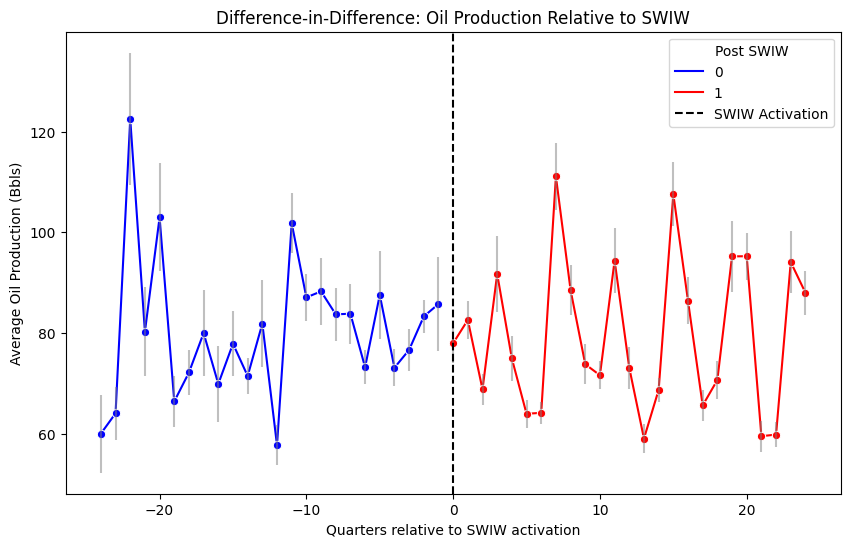

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns

# Aggregate average production by relative quarter and post
agg = prod_oil_normal[abs(prod_oil_normal['rel_quarters']) < 25].groupby(["rel_quarters", "post"]).agg(
    avg_prod=("Oil (Bbls)", "mean"),
    std_prod=("Oil (Bbls)", "std"),
    count=("Oil (Bbls)", "count")
).reset_index()

agg["se"] = agg["std_prod"] / np.sqrt(agg["count"])

plt.figure(figsize=(10,6))
sns.lineplot(
    data=agg,
    x="rel_quarters",
    y="avg_prod",
    hue="post",
    marker="o",
    palette=["blue","red"]
)

# Add error bars for SE
for i,row in agg.iterrows():
    plt.errorbar(x=row["rel_quarters"], y=row["avg_prod"], yerr=row["se"], fmt='none', color='gray', alpha=0.5)

plt.axvline(0, color="black", linestyle="--", label="SWIW Activation")
plt.xlabel("Quarters relative to SWIW activation")
plt.ylabel("Average Oil Production (Bbls)")
plt.title("Difference-in-Difference: Oil Production Relative to SWIW")
plt.legend(title="Post SWIW")
plt.show()

c:\Users\willf\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.

c:\Users\willf\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.

c:\Users\willf\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.

c:\Users\willf\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a f

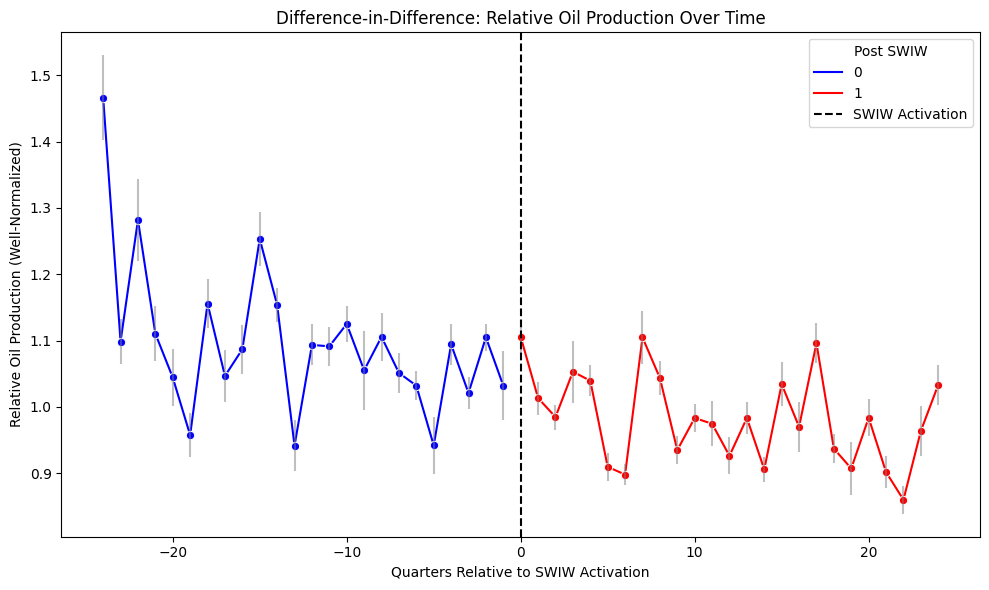

In [ ]:
prod_rel = prod_oil_normal.copy()

well_means = prod_rel.groupby("API")["Oil (Bbls)"].mean()

prod_rel["rel_prod"] = prod_rel.apply(
    lambda row: row["Oil (Bbls)"] / well_means[row["API"]],
    axis=1
)

agg = (
    prod_rel[abs(prod_rel["rel_quarters"]) < 25]
    .groupby(["rel_quarters", "post"])
    .agg(
        avg_rel_prod=("rel_prod", "mean"),
        std_rel_prod=("rel_prod", "std"),
        count=("rel_prod", "count")
    )
    .reset_index()
)

agg["se"] = agg["std_rel_prod"] / np.sqrt(agg["count"])

plt.figure(figsize=(10, 6))

sns.lineplot(
    data=agg,
    x="rel_quarters",
    y="avg_rel_prod",
    hue="post",
    marker="o",
    palette=["blue", "red"],
)

# Add SE bars
for _, row in agg.iterrows():
    plt.errorbar(
        x=row["rel_quarters"],
        y=row["avg_rel_prod"],
        yerr=row["se"],
        fmt="none",
        color="gray",
        alpha=0.5
    )

plt.axvline(0, color="black", linestyle="--", label="SWIW Activation")

plt.xlabel("Quarters Relative to SWIW Activation")
plt.ylabel("Relative Oil Production (Well-Normalized)")
plt.title("Difference-in-Difference: Relative Oil Production Over Time")
plt.legend(title="Post SWIW")

plt.tight_layout()
plt.show()


c:\Users\willf\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.

c:\Users\willf\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.

c:\Users\willf\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.

c:\Users\willf\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a f

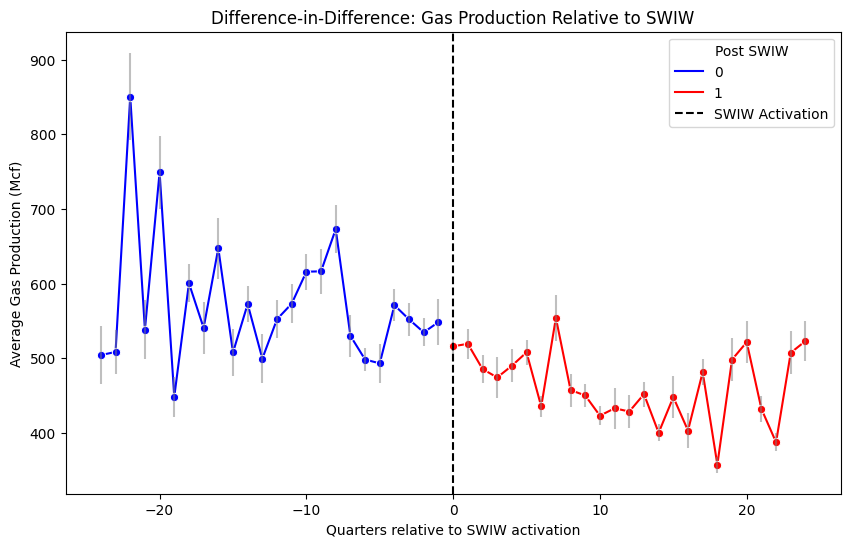

In [67]:
# Aggregate average production by relative quarter and post
agg = prod_gas_normal[abs(prod_gas_normal['rel_quarters']) < 25].groupby(["rel_quarters", "post"]).agg(
    avg_prod=("Gas (Mcf)", "mean"),
    std_prod=("Gas (Mcf)", "std"),
    count=("Gas (Mcf)", "count")
).reset_index()

agg["se"] = agg["std_prod"] / np.sqrt(agg["count"])

plt.figure(figsize=(10,6))
sns.lineplot(
    data=agg,
    x="rel_quarters",
    y="avg_prod",
    hue="post",
    marker="o",
    palette=["blue","red"]
)

# Add error bars for SE
for i,row in agg.iterrows():
    plt.errorbar(x=row["rel_quarters"], y=row["avg_prod"], yerr=row["se"], fmt='none', color='gray', alpha=0.5)

plt.axvline(0, color="black", linestyle="--", label="SWIW Activation")
plt.xlabel("Quarters relative to SWIW activation")
plt.ylabel("Average Gas Production (Mcf)")
plt.title("Difference-in-Difference: Gas Production Relative to SWIW")
plt.legend(title="Post SWIW")
plt.show()

c:\Users\willf\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.

c:\Users\willf\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.

c:\Users\willf\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.

c:\Users\willf\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a f

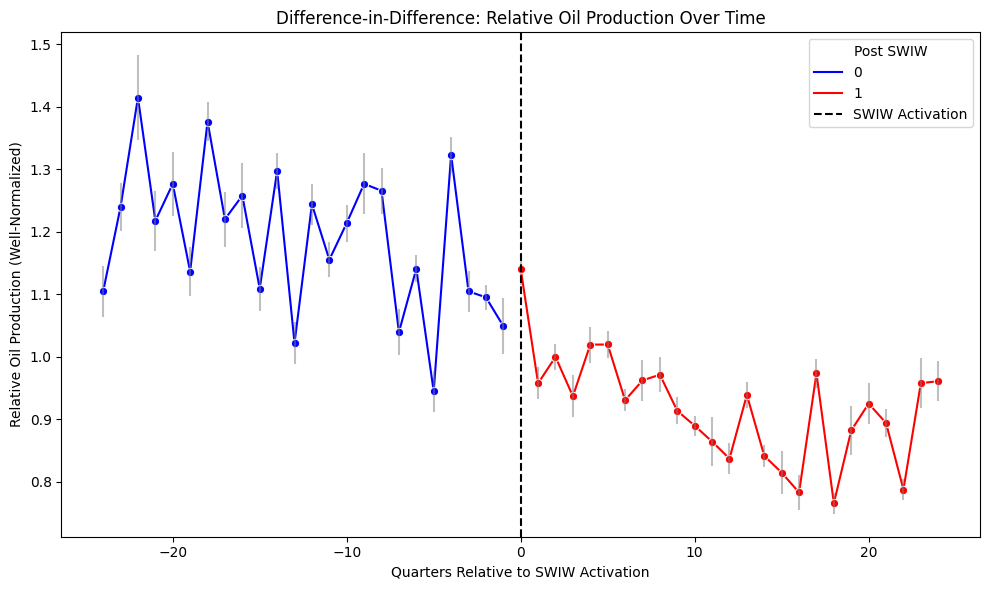

In [68]:
prod_rel = prod_gas_normal.copy()

well_means = prod_rel.groupby("API")["Gas (Mcf)"].mean()

prod_rel["rel_prod"] = prod_rel.apply(
    lambda row: row["Gas (Mcf)"] / well_means[row["API"]],
    axis=1
)

agg = (
    prod_rel[abs(prod_rel["rel_quarters"]) < 25]
    .groupby(["rel_quarters", "post"])
    .agg(
        avg_rel_prod=("rel_prod", "mean"),
        std_rel_prod=("rel_prod", "std"),
        count=("rel_prod", "count")
    )
    .reset_index()
)

agg["se"] = agg["std_rel_prod"] / np.sqrt(agg["count"])

plt.figure(figsize=(10, 6))

sns.lineplot(
    data=agg,
    x="rel_quarters",
    y="avg_rel_prod",
    hue="post",
    marker="o",
    palette=["blue", "red"],
)

# Add SE bars
for _, row in agg.iterrows():
    plt.errorbar(
        x=row["rel_quarters"],
        y=row["avg_rel_prod"],
        yerr=row["se"],
        fmt="none",
        color="gray",
        alpha=0.5
    )

plt.axvline(0, color="black", linestyle="--", label="SWIW Activation")

plt.xlabel("Quarters Relative to SWIW Activation")
plt.ylabel("Relative Oil Production (Well-Normalized)")
plt.title("Difference-in-Difference: Relative Oil Production Over Time")
plt.legend(title="Post SWIW")

plt.tight_layout()
plt.show()